# 발음 스타일별 음성 분석 파이프라인 (Accent Style Analysis)

**신호 및 시스템 - Term Project**

문장: `I think this signal processing project is really interesting.`

이 노트북은 같은 영어 문장을 **세 가지 발음 스타일**(미국식 / 한국식 / 일본식)로 발화한 음성을
Fourier 분석 도구로 비교하고, 한국식·일본식 발음을 미국식에 가깝게 변환하는 실험을 수행합니다.

### 설계 원칙
- **파일명만 바꾸면** Papago 저장본이든 직접 녹음한 음성이든 똑같이 동작합니다.
- 단어 경계 시간을 **손으로 적지 않습니다.** 에너지(RMS) 기반 **자동 구간분할**로 발화 덩어리를 찾습니다.
- 자동 구간분할 결과를 보고, **원하는 덩어리에 단어 라벨만 붙여** 특정 단어를 정밀 분석합니다.
- 나라별 발화 길이가 다른 것은 **분석 대상(발화 속도 차이)** 이며, 비교 시에는 시간축을 0~1로 정규화합니다.

### 분석 흐름
1. 설정 / 로드 (자동 trim)
2. Waveform / FFT / Spectrogram 비교
3. Frame-level feature (RMS, Spectral Centroid, ZCR, Pitch) — 1회 계산 후 캐싱
4. 시간 정규화 overlay 비교
5. **자동 구간분할** (RMS 임계값 기반)
6. **특정 단어 정밀 분석** (자동 구간에 라벨 부여)
7. MFCC 비교
8. 한국식/일본식 → 미국식 변환 실험 + 한계 분석


## 0. 라이브러리 import

In [21]:
# ==============================
# 0. Import libraries
# ==============================
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

%matplotlib inline

# 한글 폰트 (환경에 맞는 것으로. 윈도우면 'Malgun Gothic', 맥이면 'AppleGothic')
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True


## 1. 설정 & 파일 로드

**여기만 바꾸면 됩니다.** 개발할 때는 Papago 저장본으로 돌려보고,
최종 제출은 직접 녹음한 3개 파일로 `target_files`만 교체하세요.
(Term Project 요구사항: 최소 3개 이상 **직접 녹음**한 음성 필수)

- `librosa.load(... sr=sr_target)` 로 모든 파일을 같은 샘플레이트로 리샘플 → 비교가 공정해집니다.
- `librosa.effects.trim` 으로 앞뒤 묵음 제거 → 길이 비교가 발화 자체 기준이 됩니다.


In [22]:
# ==============================
# 1. Config
# ==============================
# !! 먼저 폴더 안 실제 파일명을 확인하세요. 아래 한 줄을 먼저 돌려보면 됩니다:
#    import os; print(os.listdir("PaPago_m4a"))
# 출력된 이름을 그대로 복사해서 target_files 값에 넣으세요. (오타 'Papage' 주의!)

DATA_DIR = "PaPago_m4a"    # 노트북과 같은 위치의 하위 폴더 (언더스코어!)

# --- (A) 개발/디버깅용: Papago 저장본 (Interesting 문장) ---
# 문장: "I think this signal processing project is really interesting."
target_files = {
    "US":    "Interesting_Papago_English.m4a",
    "Korea": "Interesting_Papage_Korea.m4a",   # ← 실제 파일이 'Papage' 오타면 그대로! 확인 필수
    "Japan": "Interesting_Papago_Japan.m4a",
}

# --- (B) 최종 제출용: 직접 녹음 (위를 주석 처리하고 아래 사용) ---
# 같은 문장을 세 가지 스타일로 녹음:
# target_files = {
#     "US":    "MyVoice_Imitation.m4a",   # Papago 미국식을 듣고 따라 한 발음
#     "Korea": "MyVoice_Korean.m4a",      # 평소 한국식 영어 발음
#     "Japan": "MyVoice_Japanese.m4a",    # 일본식 영어 발음 흉내
# }

sr_target = 22050          # 분석용 공통 샘플레이트
TRIM_DB = 30               # 앞뒤 묵음 제거 임계값 (작을수록 많이 자름)

# STFT 공통 파라미터 (노트북 전체에서 재사용)
n_fft = 1024
hop_length = 256
frame_length = 1024

print("Working dir:", os.getcwd())
print("Files in DATA_DIR:")
for f in sorted(os.listdir(DATA_DIR)):
    if f.endswith(('.m4a', '.wav', '.mp3')):
        print("  ", f)


Working dir: c:\Users\yhcat\OneDrive\바탕 화면\3-1학기\Speech_Processing\HailMary
Files in DATA_DIR:
   BrownDog_Papago_English.m4a
   BrownDog_Papago_Japan.m4a
   BrownDog_Papago_Korea.m4a
   Interesting_Papage_Korea.m4a
   Interesting_Papago_English.m4a
   Interesting_Papago_Japan.m4a
   Pizza_Papago_English.m4a
   Pizza_Papago_Japan.m4a
   Pizza_Papago_Korea.m4a


In [23]:
# ==============================
# 2. Load + auto-trim
# ==============================
signals = {}

for style, filename in target_files.items():
    path = os.path.join(DATA_DIR, filename)
    y, sr = librosa.load(path, sr=sr_target, mono=True)

    # 앞뒤 묵음 제거 (직접 녹음 시 특히 중요)
    y_trim, idx = librosa.effects.trim(y, top_db=TRIM_DB)

    signals[style] = {
        "y": y_trim,
        "sr": sr,
        "duration": len(y_trim) / sr,
        "filename": filename,
    }

print(f"{'style':8s} {'duration(s)':>12s}  file")
for style, d in signals.items():
    print(f"{style:8s} {d['duration']:>12.3f}  {d['filename']}")

# 길이 차이 = 발화 속도 차이 -> 분석 포인트 (보고서에 언급)
durs = {s: d["duration"] for s, d in signals.items()}
ref = durs["US"]
print("\n[발화 속도 비교] US 기준 상대 길이:")
for s, v in durs.items():
    print(f"  {s:8s}: {v/ref:.2f}x")


style     duration(s)  file
US              3.042  Interesting_Papago_English.m4a
Korea           5.364  Interesting_Papage_Korea.m4a
Japan           4.830  Interesting_Papago_Japan.m4a

[발화 속도 비교] US 기준 상대 길이:
  US      : 1.00x
  Korea   : 1.76x
  Japan   : 1.59x


## 2. Waveform / FFT / Spectrogram 비교

세 발음을 한 figure 안에 나란히 놓고 비교합니다.

> **읽는 법**
> - Waveform: 발화 길이, 강세 위치(진폭이 큰 구간)
> - FFT: 전체 평균 주파수 분포. 단, 전체에 한 번 FFT를 걸면 피크가 뭉개지므로 **참고용**입니다. 정밀 비교는 Spectrogram을 보세요.
> - Spectrogram: 시간에 따른 주파수 변화 = 실제 분석의 메인 도구


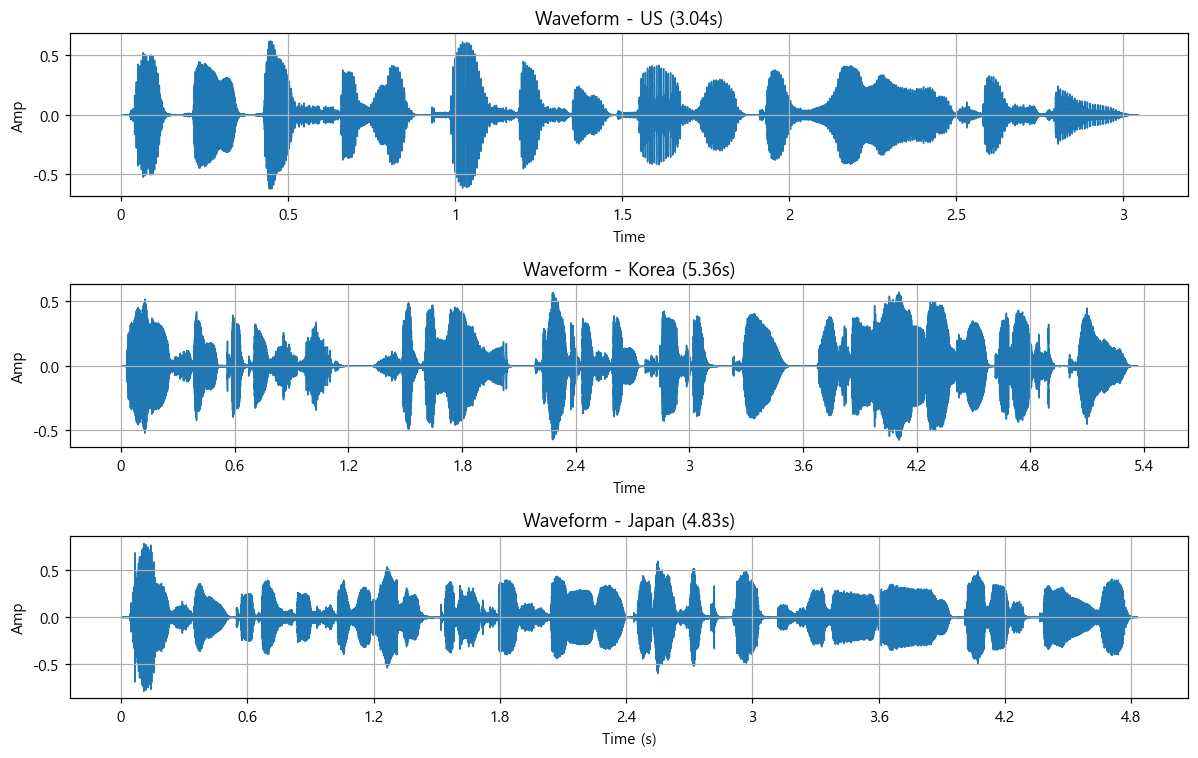

In [24]:
# ==============================
# 3. Waveform comparison
# ==============================
def plot_waveforms(signals, title_prefix="Waveform"):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.0*n + 1), sharex=False)
    if n == 1:
        axes = [axes]
    for ax, (style, d) in zip(axes, signals.items()):
        librosa.display.waveshow(d["y"], sr=d["sr"], ax=ax)
        ax.set_title(f"{title_prefix} - {style} ({d['duration']:.2f}s)")
        ax.set_ylabel("Amp")
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_waveforms(signals)


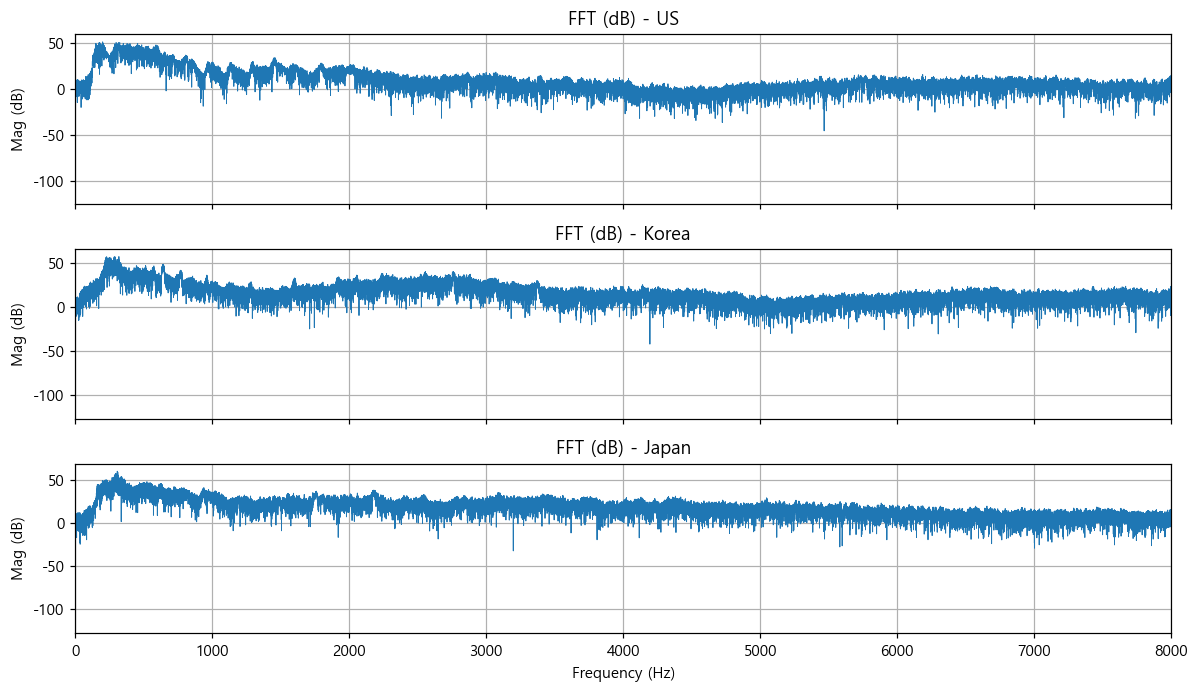

In [25]:
# ==============================
# 4. FFT magnitude spectrum (참고용 - 전체 평균)
# ==============================
def plot_fft_comparison(signals, max_freq=8000):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(11, 1.8*n + 1), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, (style, d) in zip(axes, signals.items()):
        y, sr = d["y"], d["sr"]
        Y = np.fft.rfft(y)
        freqs = np.fft.rfftfreq(len(y), d=1/sr)
        mag = np.abs(Y)
        # dB 스케일이 읽기 쉬움
        mag_db = 20*np.log10(mag + 1e-6)
        ax.plot(freqs, mag_db, linewidth=0.6)
        ax.set_title(f"FFT (dB) - {style}")
        ax.set_ylabel("Mag (dB)")
        ax.set_xlim(0, max_freq)
    axes[-1].set_xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

plot_fft_comparison(signals)


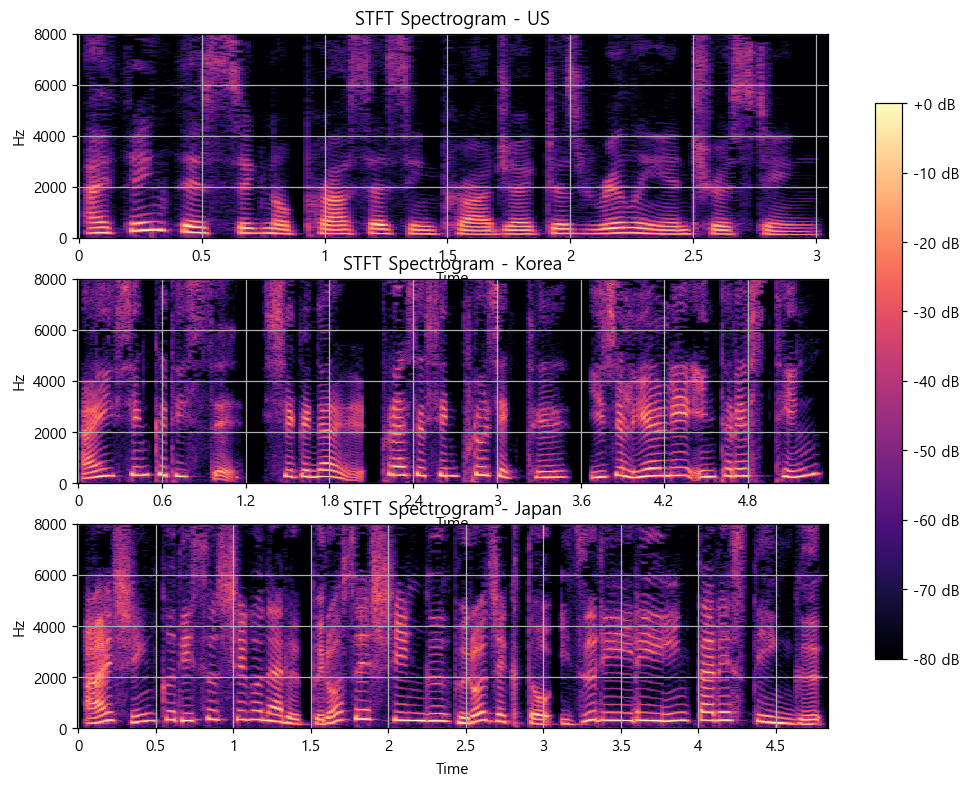

In [26]:
# ==============================
# 5. Spectrogram comparison (메인 분석 도구)
# ==============================
def plot_spectrograms(signals, max_freq=8000):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.4*n + 1), sharex=False)
    if n == 1:
        axes = [axes]
    last = None
    for ax, (style, d) in zip(axes, signals.items()):
        D = librosa.stft(d["y"], n_fft=n_fft, hop_length=hop_length, window="hann")
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        last = librosa.display.specshow(S_db, sr=d["sr"], hop_length=hop_length,
                                        x_axis="time", y_axis="hz", ax=ax)
        ax.set_ylim(0, max_freq)
        ax.set_title(f"STFT Spectrogram - {style}")
    fig.colorbar(last, ax=axes, format="%+2.0f dB", shrink=0.8)
    plt.show()

plot_spectrograms(signals)


## 3. Frame-level feature 분석 (1회 계산 후 캐싱)

전체 음성을 짧은 frame(약 12ms hop) 단위로 쪼개 시간에 따른 특징을 봅니다.
**pyin(피치 추정)은 느리므로 발음당 한 번만 계산하고 캐시**에 저장해 재사용합니다.

| feature | 의미 | accent에서 보는 것 |
|---|---|---|
| RMS energy | 구간별 소리 크기 | 강세 패턴 |
| Spectral centroid | 주파수 무게중심 | 자음 선명도 / 밝기 |
| ZCR | 영점 교차율 | 무성자음·마찰음 |
| Pitch (F0) | 기본 주파수 | 억양 변화 |


In [27]:
# ==============================
# 6. Frame-level features (캐싱)
# ==============================
_feature_cache = {}

def get_features(style):
    '''style별로 한 번만 계산하고 캐시. y가 바뀌면 캐시 키도 바뀜.'''
    d = signals[style]
    key = (style, len(d["y"]))
    if key in _feature_cache:
        return _feature_cache[key]

    y, sr = d["y"], d["sr"]
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
    f0, voiced_flag, _ = librosa.pyin(
        y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"),
        frame_length=frame_length, hop_length=hop_length)
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

    feat = {"times": times, "rms": rms, "centroid": centroid,
            "zcr": zcr, "pitch": f0, "voiced_flag": voiced_flag}
    _feature_cache[key] = feat
    return feat

# 미리 모두 계산 (시간이 좀 걸림)
for style in signals:
    get_features(style)
print("features cached for:", list(signals.keys()))


features cached for: ['US', 'Korea', 'Japan']


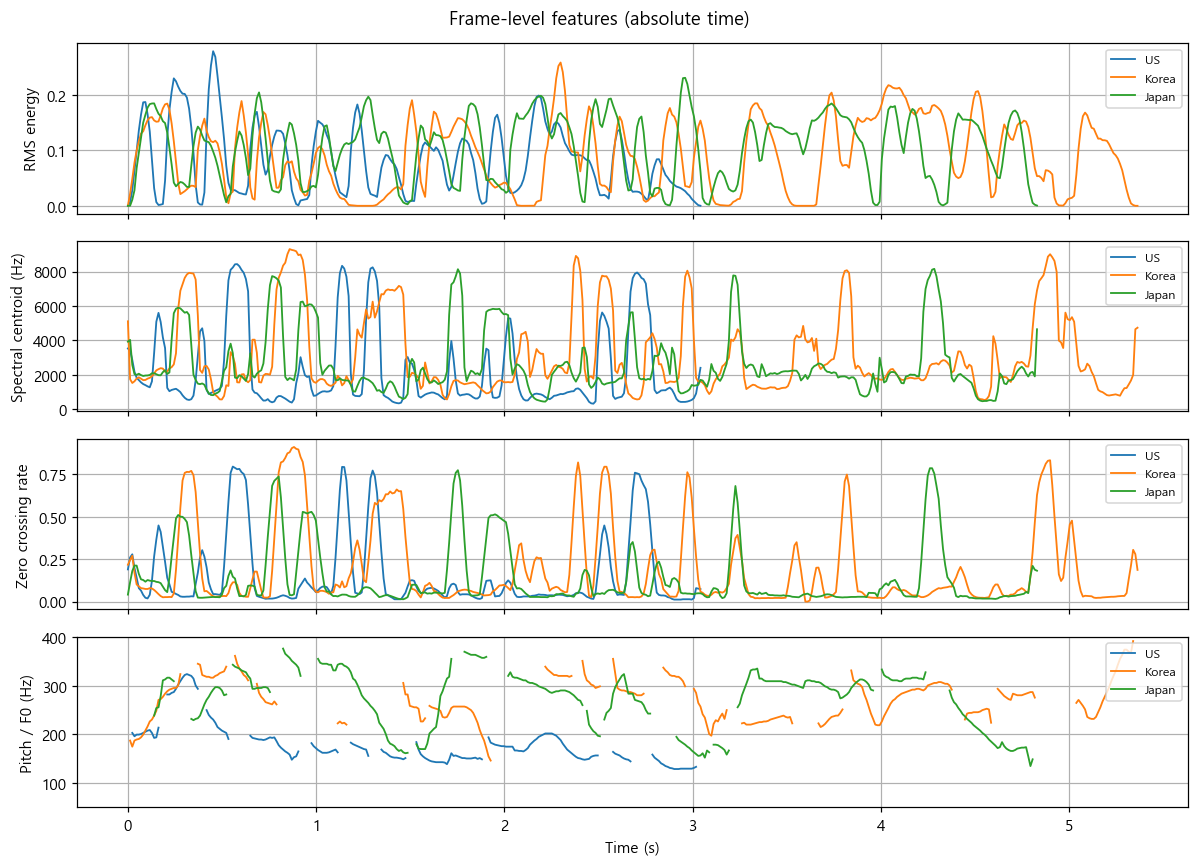

In [28]:
# ==============================
# 7. Frame-level features subplot (절대 시간축)
# ==============================
def plot_all_features(styles=None):
    styles = styles or list(signals.keys())
    specs = [("rms", "RMS energy", None),
             ("centroid", "Spectral centroid (Hz)", None),
             ("zcr", "Zero crossing rate", None),
             ("pitch", "Pitch / F0 (Hz)", (50, 400))]
    fig, axes = plt.subplots(len(specs), 1, figsize=(11, 8), sharex=True)
    for ax, (name, ylabel, ylim) in zip(axes, specs):
        for style in styles:
            f = get_features(style)
            ax.plot(f["times"], f[name], label=style, linewidth=1.2)
        ax.set_ylabel(ylabel)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Time (s)")
    plt.suptitle("Frame-level features (absolute time)")
    plt.tight_layout()
    plt.show()

plot_all_features()


## 4. 시간 정규화 overlay 비교

나라별 길이가 다르므로(예: 일본식이 미국식보다 길다), 시간축을 **0~1로 정규화**해서
같은 발화 위치끼리 겹쳐 비교합니다. 이러면 "어느 단어 즈음에서 피치/에너지가 어떻게 다른지"를
길이 차이에 방해받지 않고 볼 수 있습니다.


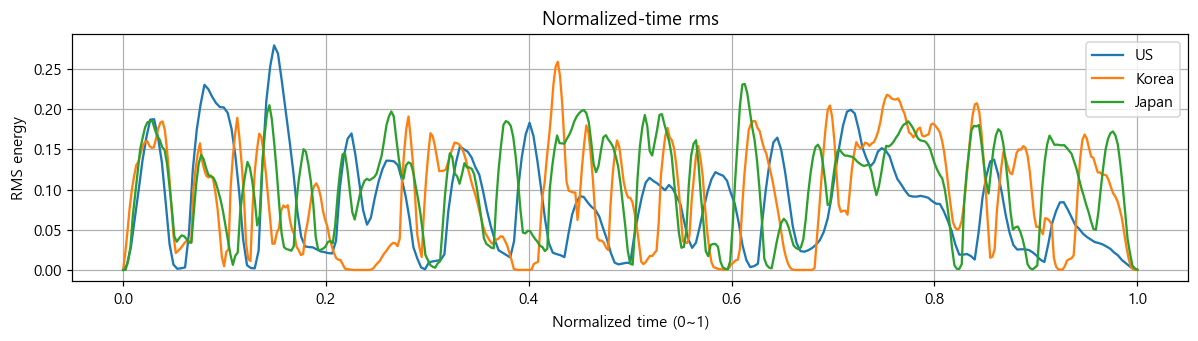

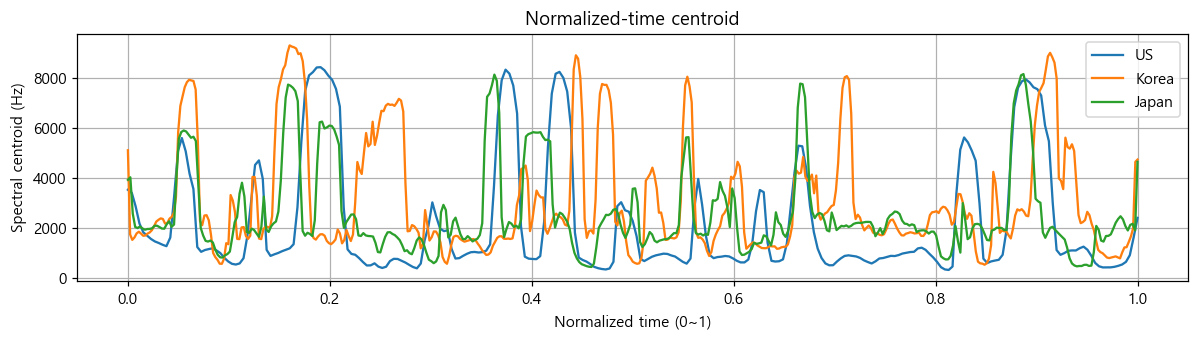

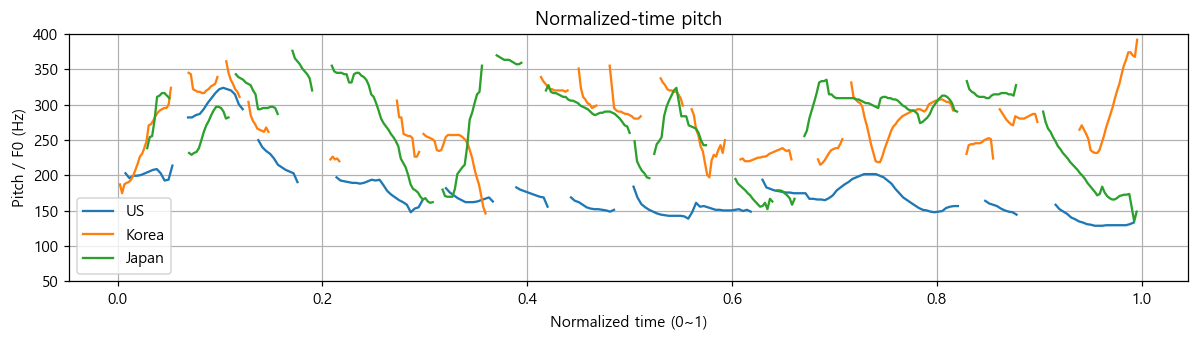

In [29]:
# ==============================
# 8. Normalized-time overlay
# ==============================
def plot_normalized(feature_name, ylabel=None, ylim=None):
    plt.figure(figsize=(11, 3.2))
    for style in signals:
        f = get_features(style)
        t = f["times"]
        t_norm = t / t[-1] if t[-1] > 0 else t   # 0~1 정규화
        plt.plot(t_norm, f[feature_name], label=style, linewidth=1.5)
    plt.title(f"Normalized-time {feature_name}")
    plt.xlabel("Normalized time (0~1)")
    plt.ylabel(ylabel or feature_name)
    if ylim: plt.ylim(*ylim)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_normalized("rms", "RMS energy")
plot_normalized("centroid", "Spectral centroid (Hz)")
plot_normalized("pitch", "Pitch / F0 (Hz)", ylim=(50, 400))


## 5. 자동 구간분할 (Energy-based segmentation)

**손으로 단어 시간을 적지 않습니다.** RMS 에너지가 임계값을 넘는 연속 구간을
하나의 "발화 덩어리(segment)"로 자동 검출합니다.
파일이 바뀌어도 코드를 고칠 필요가 없습니다.

> 원리: week10 자료의 RMS 기반 묵음/발화 구분과 같은 아이디어입니다.
> `top_db` 와 `min_dur` 만 조절하면 분할 민감도를 바꿀 수 있습니다.


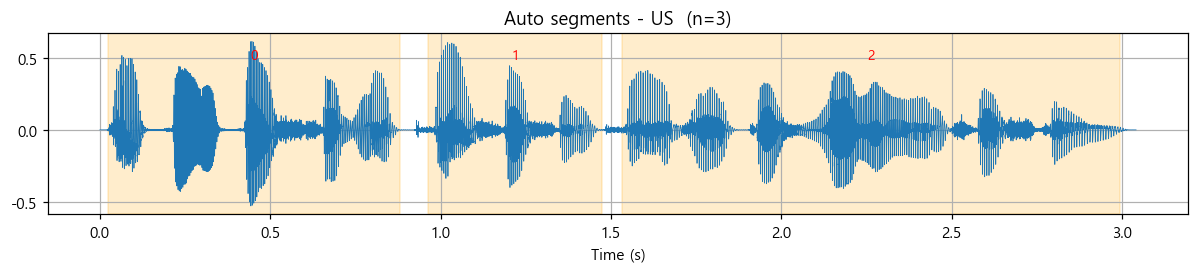

US: 3 segments -> ['0.02-0.88', '0.96-1.47', '1.53-3.00']


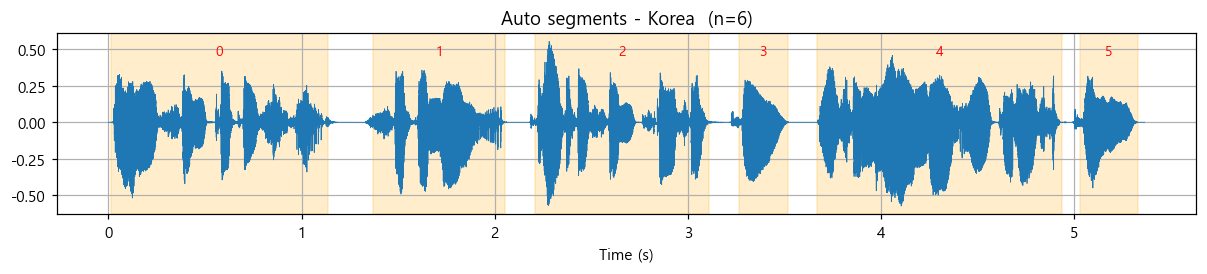

Korea: 6 segments -> ['0.01-1.14', '1.37-2.05', '2.21-3.11', '3.26-3.52', '3.67-4.93', '5.03-5.33']


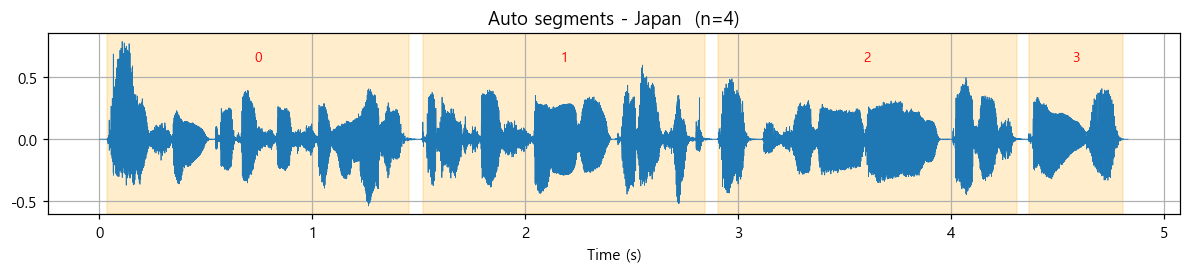

Japan: 4 segments -> ['0.03-1.45', '1.52-2.84', '2.90-4.31', '4.37-4.81']


In [41]:
# ==============================
# 9. Auto segmentation by energy
# ==============================
def auto_segments(style, top_db=25, min_dur=0.06, merge_gap=0.05):
    '''RMS 에너지 기반으로 발화 구간 [(start, end), ...] 자동 검출.
    top_db: 최대 에너지 대비 이만큼 아래는 묵음 취급
    min_dur: 이보다 짧은 구간은 버림 (초)
    merge_gap: 이보다 가까운 두 구간은 합침 (초)
    '''
    d = signals[style]
    y, sr = d["y"], d["sr"]
    # librosa.effects.split: 비묵음 구간을 샘플 인덱스로 반환
    intervals = librosa.effects.split(y, top_db=top_db,
                                      frame_length=frame_length, hop_length=hop_length)
    segs = [(s/sr, e/sr) for s, e in intervals]

    # 가까운 구간 병합
    merged = []
    for s, e in segs:
        if merged and s - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))
    # 너무 짧은 구간 제거
    merged = [(s, e) for s, e in merged if (e - s) >= min_dur]
    return merged

# 검출 + 시각화
def plot_segments(style, top_db=25, min_dur=0.06, merge_gap=0.05):
    d = signals[style]
    y, sr = d["y"], d["sr"]
    segs = auto_segments(style, top_db, min_dur, merge_gap)
    t = np.arange(len(y)) / sr

    plt.figure(figsize=(11, 2.6))
    plt.plot(t, y, linewidth=0.5)
    for i, (s, e) in enumerate(segs):
        plt.axvspan(s, e, alpha=0.2, color="orange")
        plt.text((s+e)/2, np.max(np.abs(y))*0.8, str(i),
                 ha="center", fontsize=9, color="red")
    plt.title(f"Auto segments - {style}  (n={len(segs)})")
    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
    return segs

segments_by_style = {}
for style in signals:
    segments_by_style[style] = plot_segments(style, top_db=25)
    print(f"{style}: {len(segments_by_style[style])} segments ->",
          [f"{s:.2f}-{e:.2f}" for s, e in segments_by_style[style]])


In [31]:
# ==============================
# 9b. 자동분할 = '끊어읽기 정도' 비교 지표
# ==============================
# 단어 9개와 구간 수가 정확히 안 맞는 것이 정상입니다.
# 미국식은 연음(linking)으로 매끄럽게 이어져 구간이 적고,
# 한국식/일본식은 또박또박 끊어 읽어 구간이 많아지는 경향이 있습니다.
# -> '구간 수 자체'가 발음 스타일을 구분하는 의미있는 지표가 됩니다.
seg_rows = []
for style in signals:
    segs = segments_by_style[style]
    durs = [e - s for s, e in segs]
    gaps = [segs[i+1][0] - segs[i][1] for i in range(len(segs)-1)]
    seg_rows.append({
        "style": style,
        "n_segments": len(segs),
        "mean_seg_dur": round(float(np.mean(durs)), 3) if durs else 0,
        "mean_gap": round(float(np.mean(gaps)), 3) if gaps else 0,  # 단어 사이 묵음 평균
        "total_dur": round(signals[style]["duration"], 3),
    })
df_seg = pd.DataFrame(seg_rows)
print(df_seg.to_string(index=False))
print("\n해석: n_segments↑, mean_gap↑ 이면 '또박또박 끊어 읽음'(비원어민적). "
      "미국식은 보통 구간이 적고 gap이 짧음.")


style  n_segments  mean_seg_dur  mean_gap  total_dur
   US           3         0.944     0.070      3.042
Korea           6         0.757     0.156      5.364
Japan           4         1.146     0.062      4.830

해석: n_segments↑, mean_gap↑ 이면 '또박또박 끊어 읽음'(비원어민적). 미국식은 보통 구간이 적고 gap이 짧음.


## 6. 특정 단어 정밀 분석 (자동 구간에 라벨 부여)

위 자동 분할 그림에서 각 구간에 **번호**가 붙어 있습니다.
그 번호를 보고 원하는 단어에 라벨만 매핑하면, 단어별 정밀 분석을 할 수 있습니다.

> 자동 분할은 "단어"가 아니라 "에너지 덩어리"라 단어와 1:1로 안 맞을 수 있습니다.
> 그래서 (a) 자동 구간 번호로 라벨을 붙이거나, (b) 미세 조정이 필요하면 시간을 직접 넣을 수도 있게
> 두 방식을 모두 지원합니다. **기본은 자동 구간 번호 방식**입니다.


In [32]:
# ==============================
# 10. 단어 라벨 매핑 (반자동)
# ==============================
# 문장의 단어 순서 (분석하고 싶은 핵심 단어만 골라도 됨)
WORDS = ["I", "think", "this", "signal", "processing",
         "project", "is", "really", "interesting"]

# 전략:
#  - 자동분할 구간 수가 단어 수와 정확히 같으면 1:1로 자동 매핑
#  - 다르면, 일단 '앞에서부터 순서대로' 임시 매핑하고 경고를 출력
#    -> 그림(9번)을 보고 word_label_map 을 직접 손보면 됨
def build_label_map():
    label_map = {}
    for style in signals:
        segs = segments_by_style[style]
        n_seg = len(segs)
        m = {}
        # 단어 수와 구간 수 중 작은 만큼 순서대로 매핑
        for i, w in enumerate(WORDS):
            if i < n_seg:
                m[w] = i
        label_map[style] = m
        if n_seg != len(WORDS):
            print(f"[!] {style}: 자동구간 {n_seg}개 vs 단어 {len(WORDS)}개 불일치. "
                  f"순서대로 임시 매핑함. 필요하면 word_label_map['{style}'] 직접 수정.")
    return label_map

word_label_map = build_label_map()

# (선택) 자동 구간이 부정확할 때 쓰는 수동 오버라이드.
# *** 이 파일들은 자동분할이 단어와 안 맞으므로 수동 지정을 메인으로 씁니다. ***
# 아래 값은 Papago Interesting 파일의 파형을 보고 잡은 '시작 근사값'입니다.
# 본인 녹음으로 바꾸면 6번 섹션의 waveform/segment 그림을 보고 반드시 다시 조정하세요.
# 핵심 단어 몇 개만 정밀 분석하면 충분합니다.
word_manual_override = {
    "US": {       # 총 3.22s
        "think":       (0.14, 0.60),
        "signal":      (0.88, 1.30),
        "project":     (1.68, 2.02),
        "interesting": (2.50, 2.97),
    },
    "Korea": {    # 총 5.52s (또박또박 -> 단어가 김)
        "think":       (0.27, 0.66),
        "signal":      (1.24, 2.10),
        "project":     (2.97, 3.59),
        "interesting": (4.40, 5.31),
    },
    "Japan": {    # 총 4.97s
        "think":       (0.29, 0.78),
        "signal":      (1.31, 1.99),
        "project":     (2.86, 3.33),
        "interesting": (3.95, 4.61),
    },
}

# 분석할 단어 선별: 수동 오버라이드가 있으면 그것을 우선 사용(모든 style 공통인 것만)
def safe_words():
    # 수동 오버라이드가 모든 style에 정의돼 있으면 그것을 메인으로
    if word_manual_override and all(s in word_manual_override for s in signals):
        common = None
        for s in signals:
            ws = set(word_manual_override[s].keys())
            common = ws if common is None else (common & ws)
        result = [w for w in WORDS if w in (common or set())]
        if result:
            return result
    # 아니면 자동 라벨 매핑 기준
    common = None
    for style in signals:
        ws = set(word_label_map[style].keys())
        common = ws if common is None else (common & ws)
    return [w for w in WORDS if w in (common or set())]

print("분석 가능한 단어:", safe_words())

def get_word_interval(style, word):
    if style in word_manual_override and word in word_manual_override[style]:
        return word_manual_override[style][word]
    idx = word_label_map[style][word]
    segs = segments_by_style[style]
    return segs[idx]

def crop(style, start, end):
    d = signals[style]
    return d["y"][int(start*d["sr"]):int(end*d["sr"])]


[!] US: 자동구간 3개 vs 단어 9개 불일치. 순서대로 임시 매핑함. 필요하면 word_label_map['US'] 직접 수정.
[!] Korea: 자동구간 6개 vs 단어 9개 불일치. 순서대로 임시 매핑함. 필요하면 word_label_map['Korea'] 직접 수정.
[!] Japan: 자동구간 4개 vs 단어 9개 불일치. 순서대로 임시 매핑함. 필요하면 word_label_map['Japan'] 직접 수정.
분석 가능한 단어: ['think', 'signal', 'project', 'interesting']


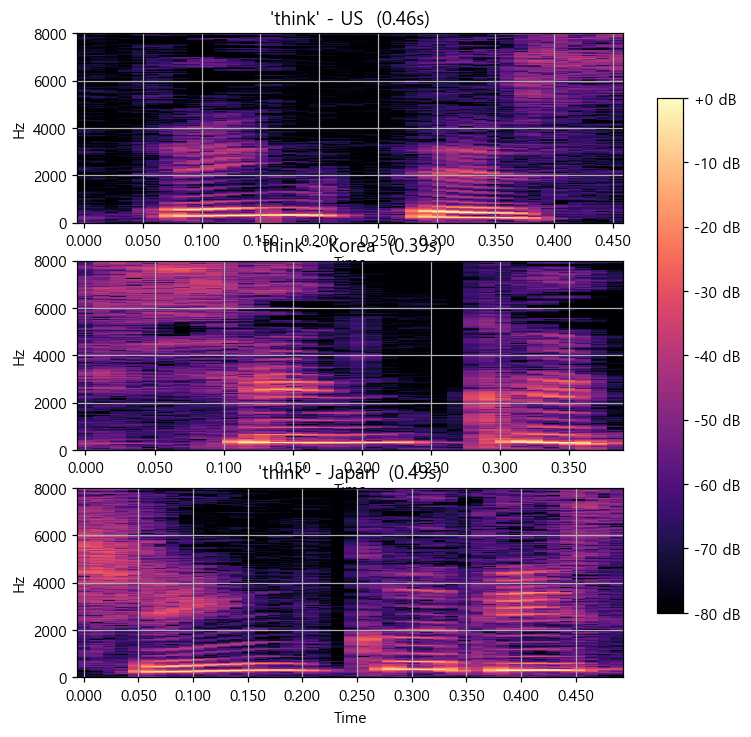

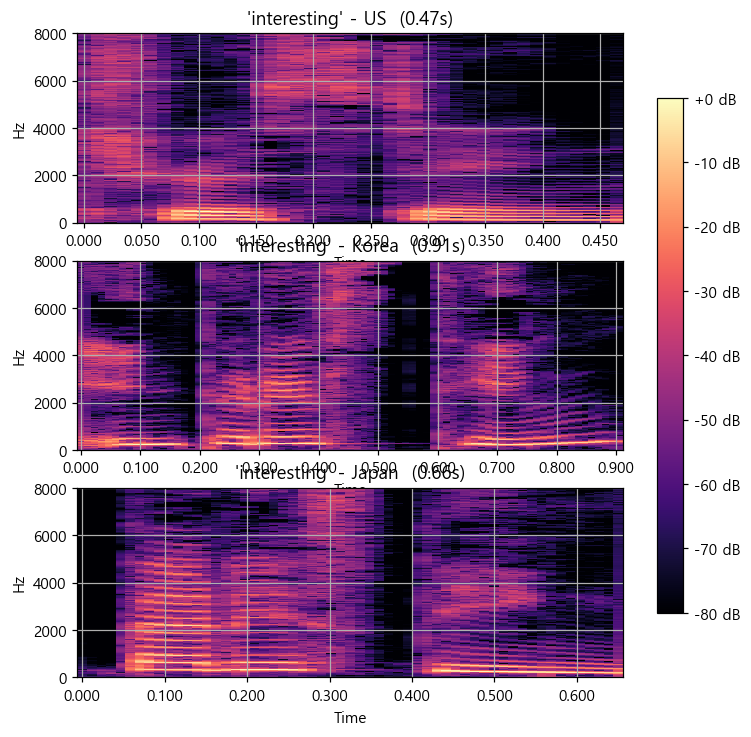

In [33]:
# ==============================
# 11. 단어별 spectrogram 비교
# ==============================
def plot_word_spectrograms(word, max_freq=8000):
    styles = list(signals.keys())
    fig, axes = plt.subplots(len(styles), 1, figsize=(8, 2.2*len(styles)+1))
    if len(styles) == 1: axes = [axes]
    last = None
    for ax, style in zip(axes, styles):
        s, e = get_word_interval(style, word)
        yw = crop(style, s, e)
        D = librosa.stft(yw, n_fft=n_fft, hop_length=hop_length)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        last = librosa.display.specshow(S_db, sr=signals[style]["sr"],
                                        hop_length=hop_length, x_axis="time",
                                        y_axis="hz", ax=ax)
        ax.set_ylim(0, max_freq)
        ax.set_title(f"'{word}' - {style}  ({e-s:.2f}s)")
    fig.colorbar(last, ax=axes, format="%+2.0f dB", shrink=0.8)
    plt.show()

# 분석하고 싶은 단어 (safe_words 중에서 자동 선택, 최대 2개)
_targets = [w for w in ["think", "interesting", "signal", "project"] if w in safe_words()]
if not _targets:
    _targets = safe_words()[:2]
for w in _targets[:2]:
    plot_word_spectrograms(w)


In [34]:
# ==============================
# 12. 단어별 feature 요약 테이블
# ==============================
def word_summary(style, word):
    s, e = get_word_interval(style, word)
    yw = crop(style, s, e)
    sr = signals[style]["sr"]
    rms = librosa.feature.rms(y=yw, frame_length=frame_length, hop_length=hop_length)[0]
    cen = librosa.feature.spectral_centroid(y=yw, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(yw, frame_length=frame_length, hop_length=hop_length)[0]
    return {"style": style, "word": word, "dur": e-s,
            "mean_rms": float(np.mean(rms)),
            "mean_centroid": float(np.mean(cen)),
            "mean_zcr": float(np.mean(zcr))}

rows = []
for style in signals:
    for word in safe_words():
        rows.append(word_summary(style, word))
df_words = pd.DataFrame(rows)
df_words


,style,word,dur,mean_rms,mean_centroid,mean_zcr
0,US,think,0.46,0.115991,3111.708963,0.228271
1,US,signal,0.42,0.073055,3045.092821,0.226087
2,US,project,0.34,0.076000,1673.926582,0.056413
3,US,interesting,0.47,0.048949,3213.240382,0.248380
4,Korea,think,0.39,0.082972,3359.252731,0.230296
5,Korea,signal,0.86,0.071420,2969.428008,0.195781
6,Korea,project,0.62,0.067965,2472.243675,0.137894
7,Korea,interesting,0.91,0.094271,3084.835857,0.169019
8,Japan,think,0.49,0.091155,2810.687934,0.136151
9,Japan,signal,0.68,0.086608,2936.379860,0.182683


## 7. MFCC 비교

MFCC는 성도(vocal tract) 모양 = 발음의 음색을 요약합니다 (수업자료 슬라이드 9~10).
발음 스타일 간 평균 MFCC 벡터의 거리로 "얼마나 다른지"를 수치화합니다.


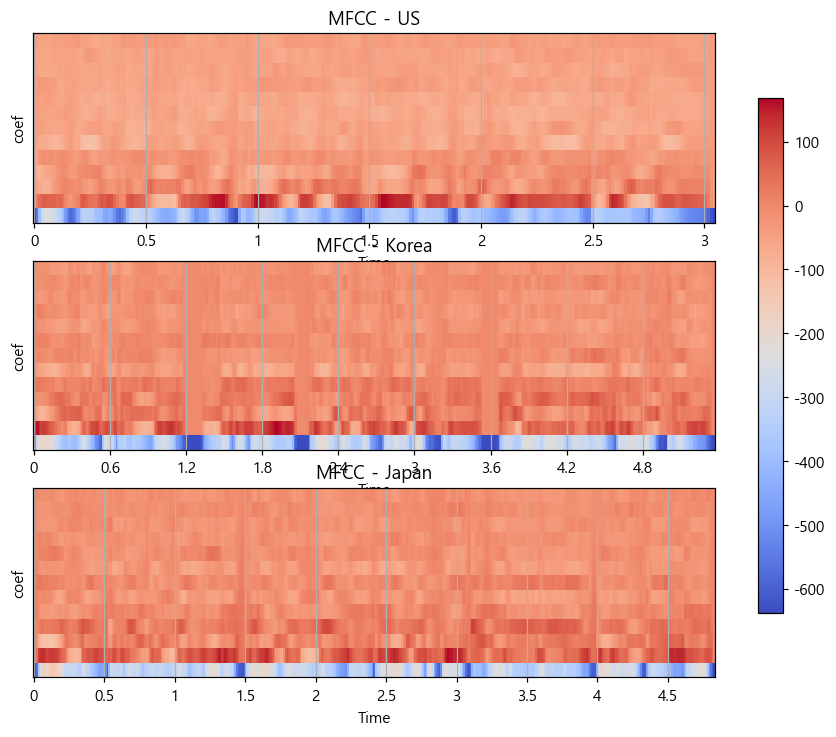

             pair   distance
0     US vs Korea  66.282944
1     US vs Japan  85.312828
2  Korea vs Japan  51.390495


In [35]:
# ==============================
# 13. MFCC heatmap + 거리
# ==============================
def plot_mfccs(signals_dict):
    n = len(signals_dict)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.2*n+1))
    if n == 1: axes = [axes]
    last = None
    mfcc_means = {}
    for ax, (style, d) in zip(axes, signals_dict.items()):
        mfcc = librosa.feature.mfcc(y=d["y"], sr=d["sr"], n_mfcc=13,
                                    n_fft=n_fft, hop_length=hop_length)
        mfcc_means[style] = mfcc.mean(axis=1)
        last = librosa.display.specshow(mfcc, sr=d["sr"], hop_length=hop_length,
                                        x_axis="time", ax=ax)
        ax.set_title(f"MFCC - {style}")
        ax.set_ylabel("coef")
    fig.colorbar(last, ax=axes, shrink=0.8)
    plt.show()
    return mfcc_means

mfcc_means = plot_mfccs(signals)

# 쌍별 거리
styles = list(mfcc_means.keys())
dist_rows = []
for i in range(len(styles)):
    for j in range(i+1, len(styles)):
        a, b = styles[i], styles[j]
        dist_rows.append({"pair": f"{a} vs {b}",
                          "distance": float(np.linalg.norm(mfcc_means[a]-mfcc_means[b]))})
df_dist = pd.DataFrame(dist_rows)
print(df_dist)


## 8. 변환 실험: 신호처리로 미국식에 "근접" 시도 + 한계 분석

> **중요한 전제:** 단순 신호처리(time/frequency 축 조작)로는 발음을 미국식으로 **바꿀 수 없습니다.**
> 한국식/일본식 영어의 핵심 차이는 **음소(phoneme) 수준**이기 때문입니다.
> 예: "th"를 s/d로 발음, 자음 뒤 모음 삽입("project"→"프로젝트"), 평평한 강세.
> 이것은 *어떤 소리를 내는가*의 문제라서, *얼마나 빠른가/밝은가*만 바꾸는 신호처리로는 해결 불가입니다.

그래서 이 실험의 목표를 **"변환 성공"이 아니라 "한계 규명"** 으로 둡니다.

조작 1. **Time stretch** — 발화 길이를 미국식에 맞춤 (속도 차이만 보정)
조작 2. **High-frequency boost** — 고주파를 키워 자음 음색을 밝게

그리고 **무엇이 미국식에 가까워졌고(속도·고주파 에너지), 무엇이 그대로인가(음소·음절 구조)** 를
정량 지표(길이, spectral centroid, 음절 수)와 스펙트로그램으로 보여줍니다.
이 "왜 안 되는가" 분석이 보고서의 **실패 분석(10점)** 입니다.


In [36]:
# ==============================
# 14. 변환 함수
# ==============================
def spectral_tilt(y, sr, cutoff=3000, gain_db=0.0):
    '''고주파 대역 이득 조정. gain_db>0이면 부스트, <0이면 감쇠.'''
    if abs(gain_db) < 1e-6:
        return y
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(len(y), d=1/sr)
    g = np.ones_like(freqs)
    g[freqs >= cutoff] = 10 ** (gain_db / 20.0)
    yb = np.fft.irfft(Y * g, n=len(y))
    m = np.max(np.abs(yb))
    return yb / m * 0.9 if m > 0 else yb

def mean_centroid(y, sr):
    return float(np.nanmean(
        librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]))

def convert_to_us_style(src_style, target_style="US"):
    y = signals[src_style]["y"]
    sr = signals[src_style]["sr"]
    src_dur = signals[src_style]["duration"]
    tgt_dur = signals[target_style]["duration"]

    # 1) 속도: src가 길면 rate>1 -> 짧아짐
    rate = src_dur / tgt_dur
    y_fast = librosa.effects.time_stretch(y, rate=rate)

    # 2) 음색: US의 centroid 쪽으로 '방향을 데이터로 결정'
    #    (무조건 부스트가 아님! src가 이미 US보다 고주파가 높으면 오히려 감쇠해야 함)
    c_src = mean_centroid(y_fast, sr)
    c_us = mean_centroid(signals[target_style]["y"], sr)
    gain_db = 4.0 if c_src < c_us else -4.0   # US보다 어두우면 +, 밝으면 -
    y_conv = spectral_tilt(y_fast, sr, cutoff=3000, gain_db=gain_db)
    return y_conv, sr, rate, gain_db, c_src, c_us

converted = {}
for src in ["Korea", "Japan"]:
    yc, sr, rate, gain_db, c_src, c_us = convert_to_us_style(src)
    converted[src] = {"y": yc, "sr": sr, "duration": len(yc)/sr, "rate": rate,
                      "filename": f"{src}_to_US.wav"}
    warn = "  <- rate가 1에서 많이 벗어남: 금속성 아티팩트 주의" if abs(rate-1) > 0.25 else ""
    direction = "부스트(+)" if gain_db > 0 else "감쇠(-)"
    print(f"{src}: stretch={rate:.3f}, 고주파 {direction} {gain_db:+.0f}dB "
          f"(src_centroid={c_src:.0f} vs US={c_us:.0f}Hz){warn}")
print("\n[발견] 만약 한국식 centroid가 US보다 높게 나오면, '고주파를 키워 미국식'이라는 "
      "처음 가정이 틀린 것 -> 보고서 분석거리.")


Korea: stretch=1.763, 고주파 감쇠(-) -4dB (src_centroid=2975 vs US=2254Hz)  <- rate가 1에서 많이 벗어남: 금속성 아티팩트 주의
Japan: stretch=1.588, 고주파 감쇠(-) -4dB (src_centroid=2523 vs US=2254Hz)  <- rate가 1에서 많이 벗어남: 금속성 아티팩트 주의

[발견] 만약 한국식 centroid가 US보다 높게 나오면, '고주파를 키워 미국식'이라는 처음 가정이 틀린 것 -> 보고서 분석거리.


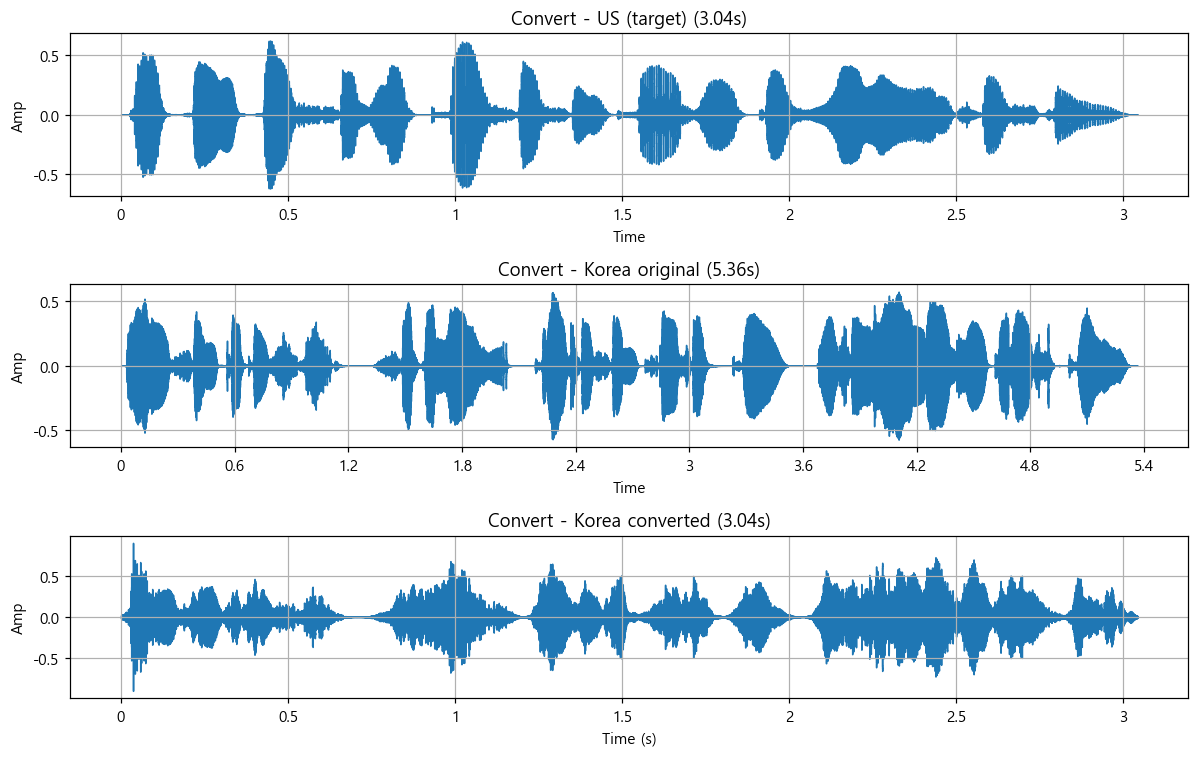

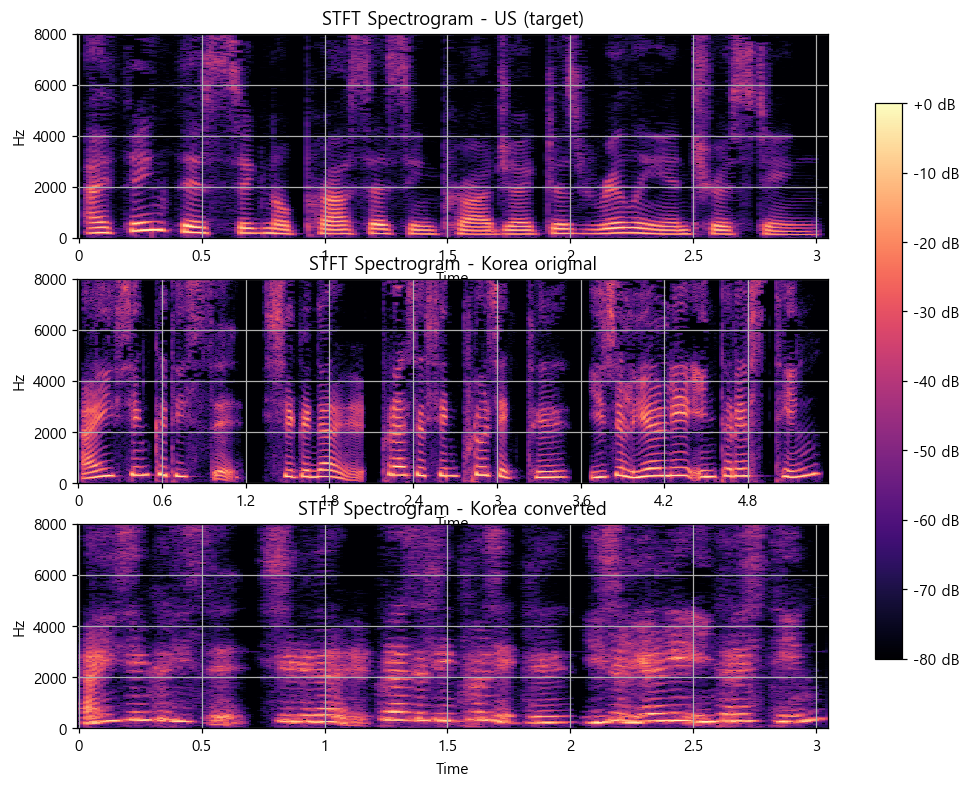

In [37]:
# ==============================
# 15. 변환 전후 비교 (한국식 예시)
# ==============================
src = "Korea"   # "Japan" 으로 바꿔서 둘 다 보기
compare = {
    "US (target)":      signals["US"],
    f"{src} original":  signals[src],
    f"{src} converted": converted[src],
}
plot_waveforms(compare, title_prefix="Convert")
plot_spectrograms(compare)


In [38]:
# ==============================
# 15b. 변환 전후 정량 비교 (무엇이 바뀌고 무엇이 안 바뀌나)
# ==============================
import scipy.signal as ss

def measure(y, sr):
    cen = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    # 음절 수 근사: RMS 에너지 피크 개수 (강세 덩어리 수)
    env = rms / (rms.max() + 1e-9)
    peaks, _ = ss.find_peaks(env, height=0.3, distance=int(0.12*sr/hop_length))
    return {"dur": len(y)/sr,
            "mean_centroid": float(np.nanmean(cen)),
            "n_syllable_approx": int(len(peaks))}

us = signals["US"]
rows = []
for src in ["Korea", "Japan"]:
    m_us  = measure(us["y"], us["sr"])
    m_org = measure(signals[src]["y"], signals[src]["sr"])
    m_cnv = measure(converted[src]["y"], converted[src]["sr"])
    for name, m in [("US(target)", m_us), (f"{src} original", m_org), (f"{src} converted", m_cnv)]:
        rows.append({"signal": name, **m})

df_change = pd.DataFrame(rows)
print(df_change.to_string(index=False))
print()
print("해석 가이드:")
print(" - dur: converted가 US에 가까워지면 -> 속도 보정은 성공")
print(" - mean_centroid: converted가 US 쪽으로 이동하면 -> 음색(고주파)은 근접")
print(" - n_syllable_approx: converted가 여전히 original과 같으면 -> 음절/음소 구조는 '안 바뀜' (한계!)")


         signal      dur  mean_centroid  n_syllable_approx
     US(target) 3.041814    2254.451192                 14
 Korea original 5.363810    3089.085010                 22
Korea converted 3.041814    2567.221068                 16
     US(target) 3.041814    2254.451192                 14
 Japan original 4.829751    2593.004093                 19
Japan converted 3.041814    2121.043427                 16

해석 가이드:
 - dur: converted가 US에 가까워지면 -> 속도 보정은 성공
 - mean_centroid: converted가 US 쪽으로 이동하면 -> 음색(고주파)은 근접
 - n_syllable_approx: converted가 여전히 original과 같으면 -> 음절/음소 구조는 '안 바뀜' (한계!)


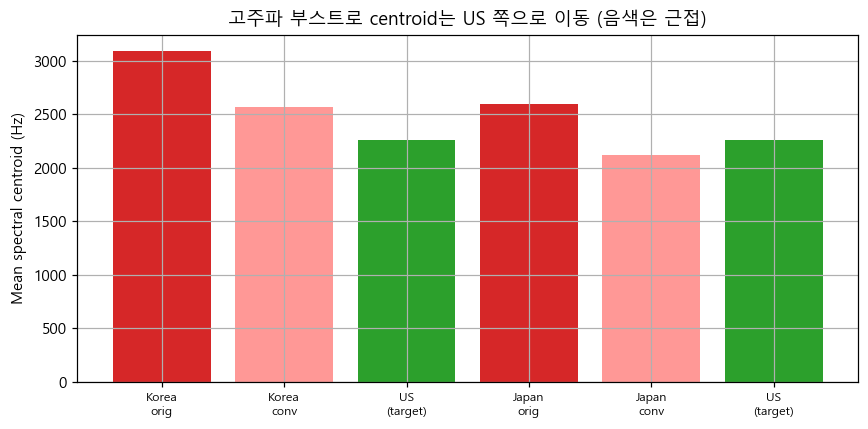

In [39]:
# ==============================
# 15c. 변환 전후 spectral centroid 시각화 (한계 시각 증거)
# ==============================
fig, ax = plt.subplots(figsize=(8, 4))
labels, values, colors = [], [], []
for src in ["Korea", "Japan"]:
    labels += [f"{src}\norig", f"{src}\nconv", "US\n(target)"]
    values += [measure(signals[src]["y"], signals[src]["sr"])["mean_centroid"],
               measure(converted[src]["y"], converted[src]["sr"])["mean_centroid"],
               measure(us["y"], us["sr"])["mean_centroid"]]
    colors += ["#d62728", "#ff9896", "#2ca02c"]
ax.bar(range(len(values)), values, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Mean spectral centroid (Hz)")
ax.set_title("고주파 부스트로 centroid는 US 쪽으로 이동 (음색은 근접)")
plt.tight_layout()
plt.show()


In [40]:
# ==============================
# 16. 변환 결과 저장 (들어볼 수 있게)
# ==============================
import soundfile as sf

OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
for src, d in converted.items():
    p = os.path.join(OUTPUT_DIR, d["filename"])
    sf.write(p, d["y"], d["sr"])
    print("saved:", p)

# 노트북에서 바로 듣기
from IPython.display import Audio, display
for src, d in converted.items():
    print(f"--- {src} converted ---")
    display(Audio(d["y"], rate=d["sr"]))


saved: ./output\Korea_to_US.wav
saved: ./output\Japan_to_US.wav
--- Korea converted ---


--- Japan converted ---


## 9. 한계 및 실패 분석 (보고서 핵심 — 실패 분석 10점)

15b/15c 셀의 정량 결과를 근거로, 신호처리 변환이 **어디까지 되고 어디서 막히는지** 정리합니다.

### 성공한 부분 (신호처리로 보정 가능)
1. **발화 속도(길이)** — `dur` 가 original → converted 에서 US 쪽으로 이동. time_stretch가 길이를 맞춤.
2. **음색의 밝기(고주파 에너지)** — `mean_centroid` 가 US 쪽으로 상승. high-frequency boost 효과.

### 실패한 부분 (신호처리로 불가능 — 한계)
3. **음소(phoneme) 자체** — "th→s/d", 자음 뒤 모음 삽입 등은 *어떤 소리를 내는가*의 문제.
   time/frequency 축 조작으로는 새로운 음소를 만들 수 없음. → 들어보면 여전히 한국식/일본식.
4. **음절 구조** — `n_syllable_approx` 가 converted 에서도 original 과 거의 같음.
   즉 "프로젝트"처럼 늘어난 음절 수가 그대로 남음 (미국식 "project"는 2음절).
   속도만 빨라졌지 음절을 합치지는 못함.
5. **부작용** — stretch rate가 1에서 멀수록(특히 일본식) phase vocoder 아티팩트(금속성 소리).
   고주파 부스트는 자음뿐 아니라 잡음·치찰음도 같이 키워 부자연스러움.
6. **가정 자체가 틀릴 수 있음** — 14번 셀 출력에서 한국식/일본식의 spectral centroid가
   미국식보다 **오히려 높게** 나올 수 있음. 그러면 "고주파를 키워 미국식에 가깝게"라는
   초기 가정이 데이터로 반증됨. (한국어 화자가 자음을 더 세게/날카롭게 내는 경향과 연결지어 해석 가능)
   → 가정을 데이터로 검증해 반증한 것 자체가 좋은 분석.

### 결론
> 단순 신호처리(DSP)는 **운율적 특징(prosody: 속도·음색·강세 일부)** 은 조정할 수 있으나,
> **분절적 특징(segmental: 음소·음절)** 은 바꾸지 못한다.
> 진정한 accent conversion은 음소를 재합성하는 모델(딥러닝 기반 voice conversion)이 필요하다.

### 개선 방향 (+α 거리)
- **포먼트(formant) 분석**(LPC)으로 모음 차이를 정량화 — 왜 음소가 다른지 수치로 증명
- **DTW(Dynamic Time Warping)** 로 길이 다른 두 발음을 정렬 → 단어 단위 자동 정합
- **pyworld(WORLD 보코더)** 로 피치·스펙트럼 envelope를 분리해 더 정교한 변환 시도


## 10. 최종 제출 체크리스트

- [ ] `target_files` 를 **직접 녹음한 3개 파일**로 교체했는가 (Papago 저장본은 개발용)
- [ ] 9번 자동분할 그림을 보고 `word_label_map` 의 구간 번호를 **내 파일에 맞게** 수정했는가
- [ ] FFT spectrum + spectrogram 결과가 보고서에 포함됐는가 (요구사항)
- [ ] 변환 실험 결과(전/후 비교)와 한계 분석이 포함됐는가
- [ ] 보고서 5페이지 이내, 맑은고딕 12pt, 그림 크기 적당히
- [ ] 마감: 6/5 23:59
